### LOAD DATASET

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("C:\\Users\\ABIN ANAND\\Desktop\\Data Science\\Projects\\E-Commerce_analysis_project\\Dataset\\ecommerce_sales_dataset.csv")

In [3]:
df.head()

,Order_ID,Customer_ID,Region,Category,Sub_Category,Product_Name,Quantity,Sales,Cost,Profit,Order_Date
0,ORD10000,CUST1654,North,Technology,Copiers,Office Copier Y,4,380.79,335.20,45.59,2022-08-17
1,ORD10001,CUST1142,North,Office Supplies,Storage,Storage Box,10,734.67,543.26,191.41,2023-03-09
2,ORD10002,CUST1032,North,Technology,Phones,iPhone Model A,9,164.46,92.49,71.97,2023-09-09
3,ORD10003,CUST1027,South,Office Supplies,Storage,File Storage,4,67.50,57.14,10.36,2023-04-05
4,ORD10004,CUST1603,East,Technology,Phones,Pixel Model C,7,605.10,473.93,131.17,2022-12-15


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order_ID      5000 non-null   object 
 1   Customer_ID   5000 non-null   object 
 2   Region        5000 non-null   object 
 3   Category      5000 non-null   object 
 4   Sub_Category  5000 non-null   object 
 5   Product_Name  5000 non-null   object 
 6   Quantity      5000 non-null   int64  
 7   Sales         5000 non-null   float64
 8   Cost          5000 non-null   float64
 9   Profit        5000 non-null   float64
 10  Order_Date    5000 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 429.8+ KB


In [5]:
df.describe()

,Quantity,Sales,Cost,Profit
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,5.469800,498.110242,346.952170,151.158072
std,2.878671,284.120737,207.615715,109.063779
min,1.000000,10.010000,5.640000,1.390000
25%,3.000000,253.262500,168.522500,63.065000
50%,5.000000,494.810000,336.890000,126.795000
75%,8.000000,740.017500,503.617500,222.437500
max,10.000000,999.420000,874.320000,486.660000


### DATA CLEANING

In [6]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [7]:
df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month

In [8]:
df = df.drop_duplicates()

In [9]:
df.isnull().sum()

Order_ID        0
Customer_ID     0
Region          0
Category        0
Sub_Category    0
Product_Name    0
Quantity        0
Sales           0
Cost            0
Profit          0
Order_Date      0
Year            0
Month           0
dtype: int64

### BASIC DATA ANALYSIS

In [10]:
total_revenue = df["Sales"].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 2490551.21


### Region wise sales

In [11]:
region_sales = df.groupby("Region")["Sales"].sum()
print(region_sales)

Region
East     595756.90
North    611594.80
South    626893.03
West     656306.48
Name: Sales, dtype: float64


### Category performance 

In [12]:
category_sales = df.groupby("Category")["Sales"].sum()
print(category_sales)

Category
Furniture          809006.71
Office Supplies    825640.98
Technology         855903.52
Name: Sales, dtype: float64


### Top 10 products

In [13]:
top_products = df.groupby("Product_Name")["Sales"].sum().sort_values(ascending=False).head(10)

print(top_products)

Product_Name
Office Chair          156627.09
Storage Box           152045.48
Office Copier X       148346.91
Binder B              145954.69
Metal Bookcase        138593.80
Ergo Chair            136957.11
Office Desk           134709.81
A4 Paper Pack         134673.59
Premium Paper Pack    131229.58
File Storage          131160.29
Name: Sales, dtype: float64


### DATA VISUALIZATION

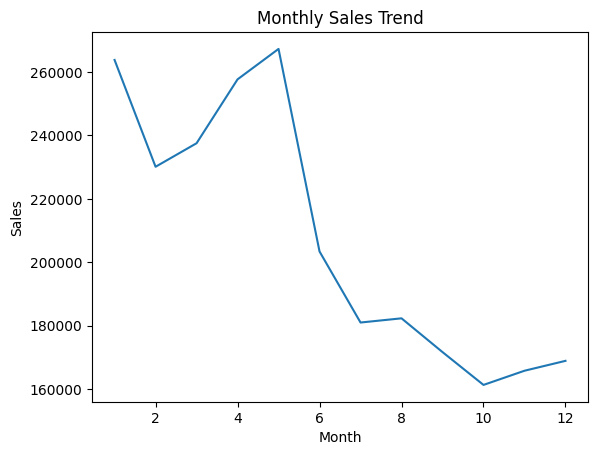

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

monthly_sales = df.groupby("Month")["Sales"].sum()

plt.figure()
monthly_sales.plot(kind="line")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

### Region sales chart

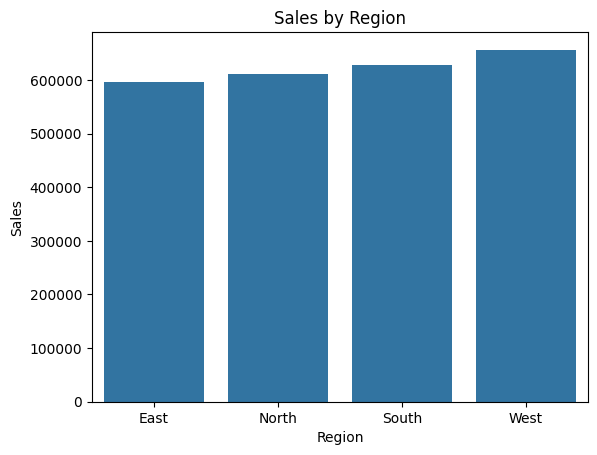

In [21]:

region_sales = df.groupby("Region")["Sales"].sum().reset_index()

sns.barplot(data=region_sales, x="Region", y="Sales")

plt.title("Sales by Region")
plt.show()

### Category sales chart

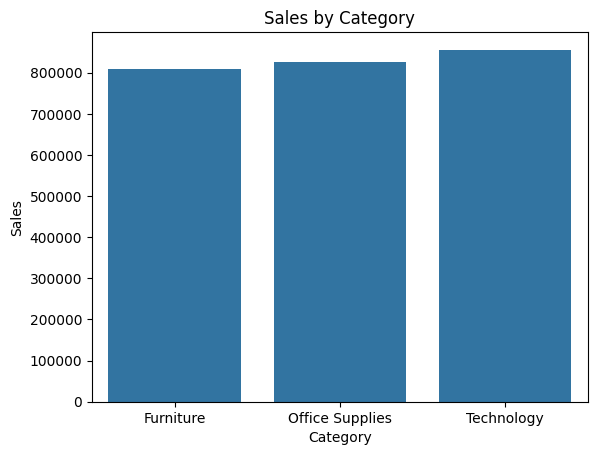

In [22]:
category_sales = df.groupby("Category")["Sales"].sum().reset_index()

sns.barplot(data=category_sales, x="Category", y="Sales")

plt.title("Sales by Category")
plt.show()

### HISTOGRAM

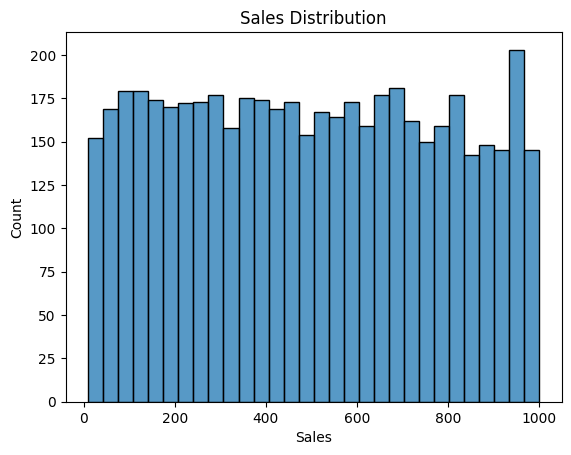

In [23]:
sns.histplot(df["Sales"], bins=30)

plt.title("Sales Distribution")
plt.show()

### BOX PLOT

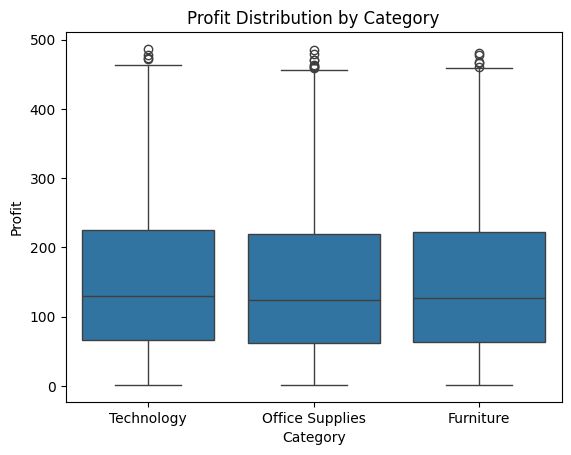

In [24]:
sns.boxplot(data=df, x="Category", y="Profit")

plt.title("Profit Distribution by Category")
plt.show()

### SCATTER PLOT

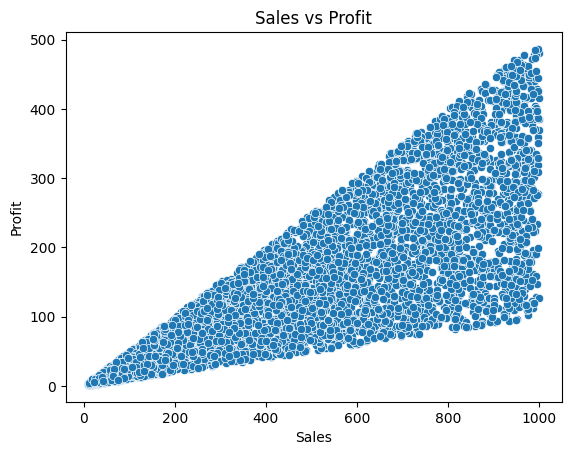

In [25]:
sns.scatterplot(data=df, x="Sales", y="Profit")

plt.title("Sales vs Profit")
plt.show()

### HEATMAP

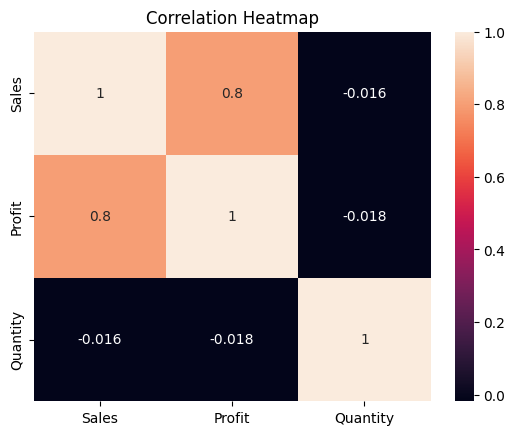

In [26]:
corr = df[["Sales", "Profit", "Quantity"]].corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")
plt.show()

### Export clean dataset

In [16]:
df.to_csv("cleaned_sales_data.csv", index=False)